# Experimento 3 — Warm Start: Splat Gaussiano inicializado desde SG

**Objetivo:** Validar que los coeficientes del filtro Savitzky-Golay 2D son suficientes para inicializar un splat gaussiano 2.5D sin optimización adicional, y cuantificar el error de recuperación de los parámetros del defecto.

**Setup:**
- Geometría nominal: cilindro tumbado $Z(X,Y) = \sqrt{R^2 - X^2}$, con $R = 52$ mm
- Defecto inyectado: gaussiana elíptica con $A = 5$ mm, $\sigma_x = 10$ mm, $\sigma_y = 20$ mm
- Sin ruido de sensor (superficie limpia)
- Unidades físicas en mm desde el principio

**Flujo:**
1. Generar imágenes sintéticas X, Y, Z en mm (tres canales co-registrados)
2. Aplicar SG 2D en espacio píxel y convertir coeficientes a unidades físicas
3. Extraer vértice sub-píxel, Hessiano y amplitud en la zona del defecto
4. Construir splat 2.5D: $\boldsymbol{\mu} \in \mathbb{R}^3$, $\boldsymbol{\Sigma} = -A \mathbf{H}^{-1}$
5. Comparar parámetros estimados vs. ground truth
6. Calcular volumen analítico $V = A \cdot 2\pi \sqrt{\det(\boldsymbol{\Sigma})}$

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import map_coordinates
from mpl_toolkits.mplot3d import Axes3D

## 1. Generación de la escena sintética

Creamos las tres imágenes co-registradas X, Y, Z que simularían la salida del sensor láser en coordenadas del mundo (mm).

In [34]:
# ── Parámetros físicos ───────────────────────────────────────────────────────
R   = 52.0   # mm  radio del cilindro
FOV_X = 120.0  # mm  campo de visión en X (transversal)
FOV_Y = 100.0  # mm  campo de visión en Y (longitudinal)
N_ROWS = 512   # píxeles en Y
N_COLS = 614   # píxeles en X  (≈ FOV_X/FOV_Y * N_ROWS)

# Resolución espacial
dx = FOV_X / N_COLS  # mm/pixel en X
dy = FOV_Y / N_ROWS  # mm/pixel en Y

print(f"Resolución: dx={dx:.4f} mm/px, dy={dy:.4f} mm/px")

# ── Grids físicos ────────────────────────────────────────────────────────────
x_vec = np.linspace(-FOV_X/2, FOV_X/2, N_COLS)  # mm
y_vec = np.linspace(-FOV_Y/2, FOV_Y/2, N_ROWS)  # mm
X_img, Y_img = np.meshgrid(x_vec, y_vec)  # (N_ROWS, N_COLS)

# ── Superficie nominal: cilindro tumbado ─────────────────────────────────────
mask_valid = np.abs(X_img) < R
Z_nominal = np.where(mask_valid, np.sqrt(np.maximum(R**2 - X_img**2, 0)), 0.0)

# ── Ground truth del defecto ─────────────────────────────────────────────────
GT_X0    = 5.0    # mm  centro X del defecto
GT_Y0    = -8.0   # mm  centro Y del defecto
GT_A     = 5.0    # mm  profundidad (amplitud positiva → el defecto baja Z)
GT_SX    = 10.0   # mm  semieje X
GT_SY    = 20.0   # mm  semieje Y

defect = GT_A * np.exp(
    -((X_img - GT_X0)**2 / (2 * GT_SX**2)
    + (Y_img - GT_Y0)**2 / (2 * GT_SY**2))
)

# ── Superficie medida = nominal − defecto (bollo hacia adentro) ───────────────
Z_img = Z_nominal - defect

# ── Volumen ground truth (integral analítica de la gaussiana) ─────────────────
V_gt = GT_A * 2 * np.pi * GT_SX * GT_SY
print(f"Ground truth: A={GT_A} mm, σx={GT_SX} mm, σy={GT_SY} mm")
print(f"Volumen ground truth: V_gt = {V_gt:.4f} mm³")

# ── Máscara de segmentación ──────────────────────────────────────────────────
# En producción esta máscara viene del modelo de segmentación.
# Aquí la construimos desde el ground truth: píxeles donde el defecto supera
# el 5% de la amplitud máxima (umbral típico de un segmentador).
SEG_THRESHOLD = 0.05  # fracción de la amplitud pico
mask_defect = defect > (SEG_THRESHOLD * GT_A)

print(f"Área de la máscara: {mask_defect.sum()} píxeles "
      f"({mask_defect.sum() * dx * dy:.1f} mm²)")

Resolución: dx=0.1954 mm/px, dy=0.1953 mm/px
Ground truth: A=5.0 mm, σx=10.0 mm, σy=20.0 mm
Volumen ground truth: V_gt = 6283.1853 mm³
Área de la máscara: 95228 píxeles (3635.0 mm²)


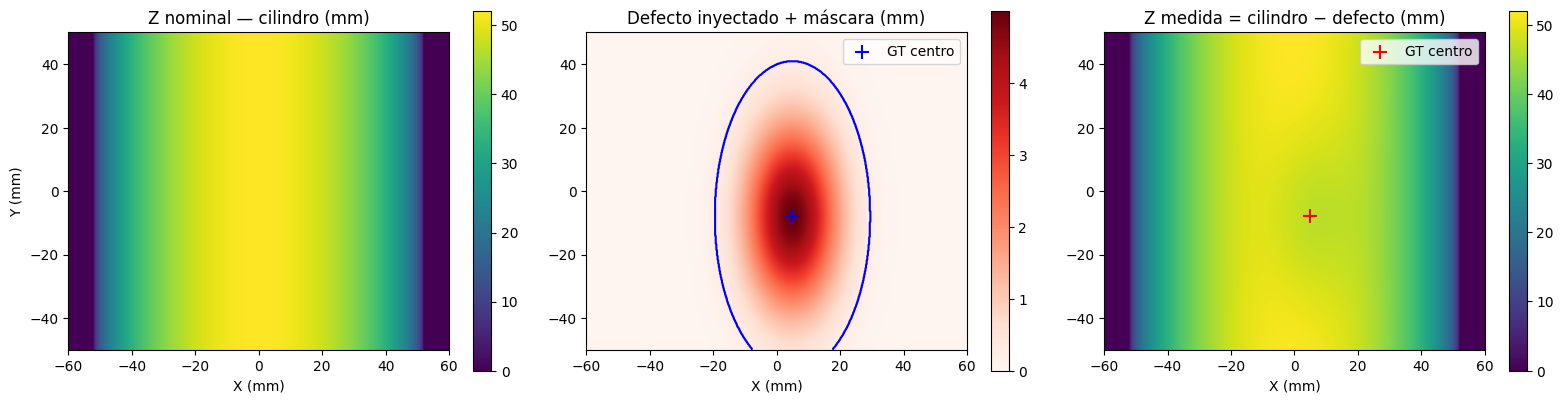

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(Z_nominal, origin='lower', extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='viridis')
axes[0].set_title("Z nominal — cilindro (mm)")
axes[0].set_xlabel("X (mm)"); axes[0].set_ylabel("Y (mm)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(defect, origin='lower', extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='Reds')
axes[1].contour(X_img, Y_img, mask_defect.astype(float), levels=[0.5],
                colors='blue', linewidths=1.5)
axes[1].scatter([GT_X0], [GT_Y0], color='blue', marker='+', s=100, label='GT centro')
axes[1].set_title("Defecto inyectado + máscara (mm)")
axes[1].set_xlabel("X (mm)")
plt.colorbar(im1, ax=axes[1])
axes[1].legend()

im2 = axes[2].imshow(Z_img, origin='lower', extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='viridis')
axes[2].scatter([GT_X0], [GT_Y0], color='red', marker='+', s=100, label='GT centro')
axes[2].set_title("Z medida = cilindro − defecto (mm)")
axes[2].set_xlabel("X (mm)")
plt.colorbar(im2, ax=axes[2])
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Filtro Savitzky-Golay 2D

Aplicamos el filtro en coordenadas píxel y luego convertimos los coeficientes a unidades físicas (mm).

Si el píxel tiene paso físico $d_x$ mm/px en X e $d_y$ mm/px en Y, la conversión es:

$$a_{\rm phys} = \frac{a_{\rm px}}{d_x^2}, \quad b_{\rm phys} = \frac{b_{\rm px}}{d_y^2}, \quad c_{\rm phys} = \frac{c_{\rm px}}{d_x d_y}$$
$$d_{\rm phys} = \frac{d_{\rm px}}{d_x}, \quad e_{\rm phys} = \frac{e_{\rm px}}{d_y}$$

El Hessiano en espacio físico queda:
$$\mathbf{H}_{\rm phys} = \begin{pmatrix} 2a_{\rm phys} & c_{\rm phys} \\ c_{\rm phys} & 2b_{\rm phys} \end{pmatrix}$$

In [36]:
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    """Filtro SG 2D por proyección. Devuelve tensor (N, M, 6) con coeficientes
    (a, b, c, d, e, f0) del paraboloide local ajustado en coordenadas píxel."""
    assert window_size % 2 == 1, "La ventana debe ser impar"
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx * y_idx,
        x_idx, y_idx, np.ones_like(x_idx)
    ], axis=-1)  # (w, w, 6)
    A_mat = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A_mat.T @ A_mat) @ A_mat.T  # (6, w²)
    kernels = pseudo.reshape(6, window_size, window_size)
    coeffs = np.stack(
        [cv2.filter2D(Z, -1, k, borderType=cv2.BORDER_REFLECT) for k in kernels],
        axis=-1
    )
    return coeffs  # (N, M, 6): [a_px, b_px, c_px, d_px, e_px, f0]


def coeffs_to_physical(coeffs_px, dx, dy):
    """Convierte coeficientes SG de espacio píxel a espacio físico (mm)."""
    a_ph = coeffs_px[..., 0] / dx**2
    b_ph = coeffs_px[..., 1] / dy**2
    c_ph = coeffs_px[..., 2] / (dx * dy)
    d_ph = coeffs_px[..., 3] / dx
    e_ph = coeffs_px[..., 4] / dy
    f0   = coeffs_px[..., 5]          # offset: ya está en mm
    return np.stack([a_ph, b_ph, c_ph, d_ph, e_ph, f0], axis=-1)

In [48]:
# ── Ventana óptima (elegida del análisis de sensibilidad §7) ─────────────────
# La sensibilidad mostró que la ventana más pequeña (20mm ≈ 1·σ_mayor) minimiza
# el error en amplitud y forma. Regla: WIN_MM ≈ σ_mayor para sin ruido.
WIN_MM  = 20.0           # mm  — mejor ventana del barrido [20,30,40,60,80,...,160]mm
WIN_PX  = int(np.round(WIN_MM / min(dx, dy)))
WIN_PX  = WIN_PX if WIN_PX % 2 == 1 else WIN_PX + 1  # impar

print(f"Ventana SG (óptima): {WIN_MM:.0f} mm → {WIN_PX} px")

# ── Imagen diferencial: profundidad del defecto ───────────────────────────────
Z_diff = Z_nominal - Z_img  # == defect (por construcción)

coeffs_px  = sg2d_jacobian_projection_cv2(Z_diff, window_size=WIN_PX)
coeffs_ph  = coeffs_to_physical(coeffs_px, dx, dy)

a_ph, b_ph, c_ph, d_ph, e_ph, f0_ph = [coeffs_ph[..., i] for i in range(6)]

Ventana SG (óptima): 20 mm → 103 px


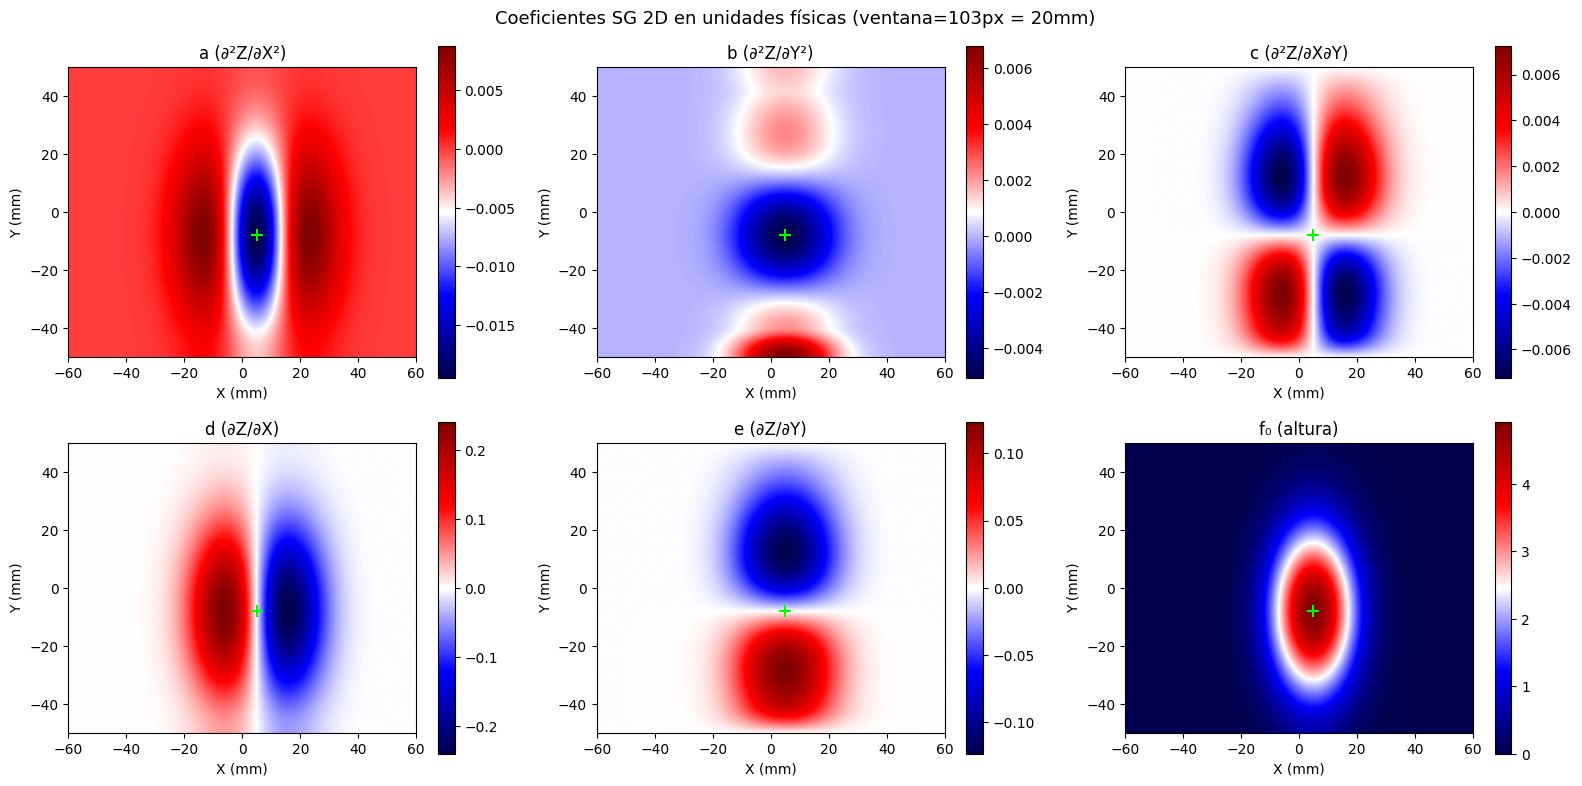

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
labels = ["a (∂²Z/∂X²)", "b (∂²Z/∂Y²)", "c (∂²Z/∂X∂Y)",
          "d (∂Z/∂X)",   "e (∂Z/∂Y)",   "f₀ (altura)"]
extent = [-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2]

for idx, (ax, lbl) in enumerate(zip(axes.flat, labels)):
    im = ax.imshow(coeffs_ph[..., idx], origin='lower', extent=extent, cmap='seismic')
    ax.scatter([GT_X0], [GT_Y0], color='lime', marker='+', s=80)
    ax.set_title(lbl)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)")
    plt.colorbar(im, ax=ax)

plt.suptitle(f"Coeficientes SG 2D en unidades físicas (ventana={WIN_PX}px = {WIN_MM:.0f}mm)",
             fontsize=13)
plt.tight_layout()
plt.show()

## 3. Extracción del vértice y Hessiano desde la máscara de segmentación

La máscara de segmentación (que en producción entrega el modelo) delimita la zona del defecto. Dentro de ella buscamos el píxel de mínimo $f_0$ (punto más bajo de la superficie medida) y calculamos el desplazamiento sub-píxel al vértice real:

$$\begin{pmatrix} \Delta X \\ \Delta Y \end{pmatrix} = -\mathbf{H}^{-1} \begin{pmatrix} d \\ e \end{pmatrix}$$

No se usa ningún conocimiento del ground truth para localizar el defecto.

In [50]:
# ── Localizar el vértice usando la máscara de segmentación ──────────────────
# Sobre el mapa diferencial (Z_nominal - Z_img), el defecto es un pico positivo.
# El máximo de f0_ph dentro de la máscara es el punto de mayor profundidad.
f0_masked = np.where(mask_defect, f0_ph, -np.inf)
peak_row, peak_col = np.unravel_index(np.argmax(f0_masked), f0_masked.shape)

# Coordenadas GT en píxel (solo para comparar, no se usan para localizar)
GT_row = int(np.round((GT_Y0 + FOV_Y/2) / dy))
GT_col = int(np.round((GT_X0 + FOV_X/2) / dx))

print(f"Píxel de máx. f0 (dentro de la máscara): fila={peak_row}, col={peak_col}")
print(f"GT en píxeles:                            fila={GT_row},   col={GT_col}")

# ── Coeficientes físicos en el píxel pico ────────────────────────────────────
a0, b0, c0_coef, d0, e0, f0_val = coeffs_ph[peak_row, peak_col, :]

# ── Hessiano y desplazamiento sub-píxel ──────────────────────────────────────
H = np.array([[2*a0, c0_coef],
              [c0_coef, 2*b0]])

grad = np.array([d0, e0])
delta_phys = -np.linalg.solve(H, grad)  # (ΔX, ΔY) en mm

# Coordenadas físicas del píxel pico
X_peak = x_vec[peak_col]
Y_peak = y_vec[peak_row]

# Centro sub-píxel estimado
mu_X = X_peak + delta_phys[0]
mu_Y = Y_peak + delta_phys[1]
# f0_val ahora es la profundidad estimada en el vértice (en mm del diferencial)
A_from_f0 = f0_val

print(f"\n── Vértice sub-píxel (SG) ──────────────────────")
print(f"  X estimado: {mu_X:.4f} mm  |  GT: {GT_X0:.4f} mm  |  error: {mu_X - GT_X0:.4f} mm")
print(f"  Y estimado: {mu_Y:.4f} mm  |  GT: {GT_Y0:.4f} mm  |  error: {mu_Y - GT_Y0:.4f} mm")
print(f"  Amplitud desde f0: {A_from_f0:.4f} mm  |  GT: {GT_A:.4f} mm")

Píxel de máx. f0 (dentro de la máscara): fila=215, col=332
GT en píxeles:                            fila=215,   col=333

── Vértice sub-píxel (SG) ──────────────────────
  X estimado: 4.9993 mm  |  GT: 5.0000 mm  |  error: -0.0007 mm
  Y estimado: -7.9983 mm  |  GT: -8.0000 mm  |  error: 0.0017 mm
  Amplitud desde f0: 4.9232 mm  |  GT: 5.0000 mm


## 4. Construcción del Splat 2.5D (Warm Start)

A partir de los coeficientes SG, construimos el splat gaussiano:

$$\boldsymbol{\mu} = (\mu_X,\; \mu_Y,\; \mu_Z) \in \mathbb{R}^3$$

$$\boldsymbol{\Sigma} = -A \cdot \mathbf{H}^{-1}, \quad \mathbf{H} = \begin{pmatrix} 2a & c \\ c & 2b \end{pmatrix}$$

La amplitud se extrae del valor del paraboloide en el vértice: $A = -f_v$ (defecto hacia adentro → $f_v$ es mínimo negativo relativo al nominal).

In [51]:
# ── Amplitud: directamente de f0 del mapa diferencial ────────────────────────
# Sobre Z_diff = Z_nominal - Z_img, f0 en el vértice es la profundidad estimada
A_splat = A_from_f0

print(f"Amplitud estimada:  A = {A_splat:.4f} mm  |  GT: {GT_A:.4f} mm  |  error: {A_splat - GT_A:.4f} mm")

# ── Covarianza del splat desde el Hessiano ───────────────────────────────────
# Z_diff es un PICO positivo -> curvatura negativa en el vertice (a < 0, b < 0).
# Para gaussiana f = A*exp(-1/2 x^T Sigma^-1 x): a = -A/(2*sx^2) -> Sigma = -A*H^-1
Sigma_splat = -A_splat * np.linalg.inv(H)

# Autovalores -> semiejes del elipsoide
eigvals, eigvecs = np.linalg.eigh(Sigma_splat)
if np.any(eigvals <= 0):
    print(f"ADVERTENCIA: Sigma no es definida positiva: eigvals={eigvals}")
else:
    print("Sigma definida positiva")

sigma1_est, sigma2_est = np.sqrt(np.abs(eigvals))
if sigma1_est < sigma2_est:
    sigma1_est, sigma2_est = sigma2_est, sigma1_est

print(f"\n-- Parametros del Splat (Warm Start) --")
print(f"  mu = ({mu_X:.4f}, {mu_Y:.4f}) mm")
print(f"  Sigma =\n{Sigma_splat}")
print(f"  sigma_mayor estimado: {sigma1_est:.4f} mm  |  GT sigma_y={GT_SY} mm")
print(f"  sigma_menor estimado: {sigma2_est:.4f} mm  |  GT sigma_x={GT_SX} mm")

# ── Volumen analitico ─────────────────────────────────────────────────────────
V_splat = A_splat * 2 * np.pi * np.sqrt(np.linalg.det(Sigma_splat))
print(f"\n-- Metrologia del Splat --")
print(f"  Volumen estimado:  V = {V_splat:.4f} mm^3")
print(f"  Volumen GT:        V = {V_gt:.4f} mm^3")
print(f"  Error relativo:    {100*(V_splat - V_gt)/V_gt:.2f} %")

Amplitud estimada:  A = 4.9232 mm  |  GT: 5.0000 mm  |  error: -0.0768 mm
Sigma definida positiva

-- Parametros del Splat (Warm Start) --
  mu = (4.9993, -7.9983) mm
  Sigma =
[[ 1.26316934e+02 -6.53191537e-04]
 [-6.53191537e-04  4.85090396e+02]]
  sigma_mayor estimado: 22.0248 mm  |  GT sigma_y=20.0 mm
  sigma_menor estimado: 11.2391 mm  |  GT sigma_x=10.0 mm

-- Metrologia del Splat --
  Volumen estimado:  V = 7657.1256 mm^3
  Volumen GT:        V = 6283.1853 mm^3
  Error relativo:    21.87 %


## 5. Tabla resumen — Estimado vs. Ground Truth

In [52]:
import pandas as pd

data = {
    "Parámetro":    ["X₀ (mm)",   "Y₀ (mm)",   "A (mm)",  "σ_mayor (mm)", "σ_menor (mm)", "V (mm³)"],
    "Ground truth": [GT_X0,        GT_Y0,        GT_A,      GT_SY,          GT_SX,          V_gt],
    "Estimado SG":  [mu_X,         mu_Y,         A_splat,   sigma1_est,     sigma2_est,     V_splat],
}
df = pd.DataFrame(data)
df["Error abs"] = (df["Estimado SG"] - df["Ground truth"]).abs()
df["Error rel %"] = 100 * df["Error abs"] / df["Ground truth"].abs()
df = df.round(4)
print(df.to_string(index=False))

   Parámetro  Ground truth  Estimado SG  Error abs  Error rel %
     X₀ (mm)        5.0000       4.9993     0.0007       0.0136
     Y₀ (mm)       -8.0000      -7.9983     0.0017       0.0217
      A (mm)        5.0000       4.9232     0.0768       1.5368
σ_mayor (mm)       20.0000      22.0248     2.0248      10.1238
σ_menor (mm)       10.0000      11.2391     1.2391      12.3908
     V (mm³)     6283.1853    7657.1256  1373.9403      21.8669


## 6. Visualización del Splat vs. Defecto real

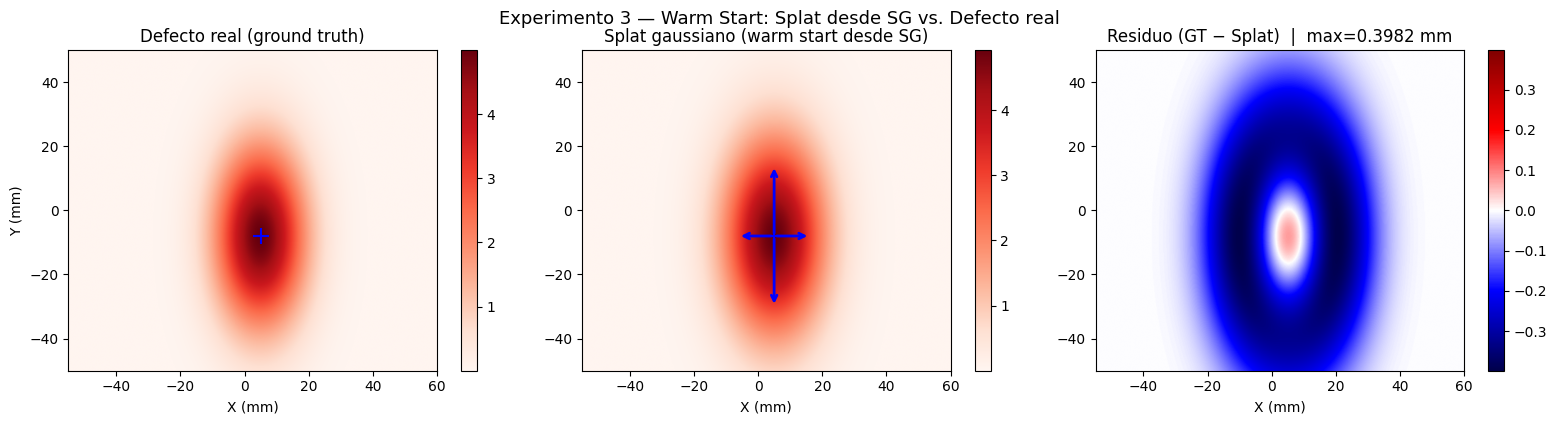

In [53]:
# Reconstruir el defecto según el splat en la imagen completa
Sigma_inv = np.linalg.inv(Sigma_splat)
dX = X_img - mu_X
dY = Y_img - mu_Y

# Evaluación vectorizada de la gaussiana 2D
exponent = 0.5 * (Sigma_inv[0,0]*dX**2
                + 2*Sigma_inv[0,1]*dX*dY
                + Sigma_inv[1,1]*dY**2)
defect_splat = A_splat * np.exp(-exponent)

# Residuo
residuo = defect - defect_splat

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
extent = [-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2]

# ROI de visualización
vis_r = int(3 * max(GT_SX, GT_SY) / dy)
vis_c = int(3 * max(GT_SX, GT_SY) / dx)
r0v = max(0, GT_row - vis_r); r1v = min(N_ROWS, GT_row + vis_r)
c0v = max(0, GT_col - vis_c); c1v = min(N_COLS, GT_col + vis_c)
ext_roi = [x_vec[c0v], x_vec[c1v-1], y_vec[r0v], y_vec[r1v-1]]

im0 = axes[0].imshow(defect[r0v:r1v, c0v:c1v], origin='lower', extent=ext_roi, cmap='Reds')
axes[0].scatter([GT_X0], [GT_Y0], color='blue', marker='+', s=120, label='GT')
axes[0].set_title("Defecto real (ground truth)")
axes[0].set_xlabel("X (mm)"); axes[0].set_ylabel("Y (mm)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(defect_splat[r0v:r1v, c0v:c1v], origin='lower', extent=ext_roi, cmap='Reds')
axes[1].scatter([mu_X], [mu_Y], color='blue', marker='+', s=120, label='Estimado')
# Dibujar los semiejes del splat
for i_eig in range(2):
    v = eigvecs[:, i_eig]
    sigma_i = np.sqrt(np.abs(eigvals[i_eig]))
    axes[1].annotate('', xy=(mu_X + v[0]*sigma_i, mu_Y + v[1]*sigma_i),
                     xytext=(mu_X, mu_Y),
                     arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    axes[1].annotate('', xy=(mu_X - v[0]*sigma_i, mu_Y - v[1]*sigma_i),
                     xytext=(mu_X, mu_Y),
                     arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axes[1].set_title("Splat gaussiano (warm start desde SG)")
axes[1].set_xlabel("X (mm)")
plt.colorbar(im1, ax=axes[1])

vmax_res = np.max(np.abs(residuo[r0v:r1v, c0v:c1v]))
im2 = axes[2].imshow(residuo[r0v:r1v, c0v:c1v], origin='lower', extent=ext_roi,
                     cmap='seismic', vmin=-vmax_res, vmax=vmax_res)
axes[2].set_title(f"Residuo (GT − Splat)  |  max={vmax_res:.4f} mm")
axes[2].set_xlabel("X (mm)")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Experimento 3 — Warm Start: Splat desde SG vs. Defecto real", fontsize=13)
plt.tight_layout()
plt.show()

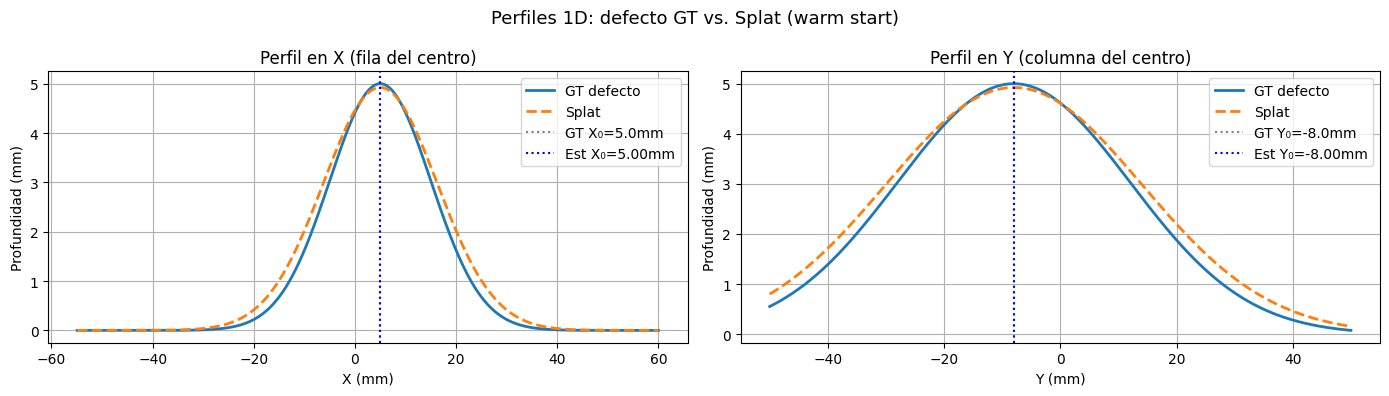

In [54]:
# Perfiles 1D a través del centro del defecto (dirección X e Y)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Perfil en X (fila del centro del defecto)
row_center = int(np.round((mu_Y + FOV_Y/2) / dy))
col_center = int(np.round((mu_X + FOV_X/2) / dx))

x_slice = x_vec[c0v:c1v]
axes[0].plot(x_slice, defect[row_center, c0v:c1v], label='GT defecto', lw=2)
axes[0].plot(x_slice, defect_splat[row_center, c0v:c1v], '--', label='Splat', lw=2)
axes[0].axvline(GT_X0, color='gray', linestyle=':', label=f'GT X₀={GT_X0}mm')
axes[0].axvline(mu_X,  color='blue', linestyle=':', label=f'Est X₀={mu_X:.2f}mm')
axes[0].set_title("Perfil en X (fila del centro)")
axes[0].set_xlabel("X (mm)"); axes[0].set_ylabel("Profundidad (mm)")
axes[0].legend(); axes[0].grid(True)

# Perfil en Y (columna del centro del defecto)
y_slice = y_vec[r0v:r1v]
axes[1].plot(y_slice, defect[r0v:r1v, col_center], label='GT defecto', lw=2)
axes[1].plot(y_slice, defect_splat[r0v:r1v, col_center], '--', label='Splat', lw=2)
axes[1].axvline(GT_Y0, color='gray', linestyle=':', label=f'GT Y₀={GT_Y0}mm')
axes[1].axvline(mu_Y,  color='blue', linestyle=':', label=f'Est Y₀={mu_Y:.2f}mm')
axes[1].set_title("Perfil en Y (columna del centro)")
axes[1].set_xlabel("Y (mm)"); axes[1].set_ylabel("Profundidad (mm)")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Perfiles 1D: defecto GT vs. Splat (warm start)", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Sensibilidad al tamaño de ventana SG

Analizamos cómo varía el error de estimación de $A$, $\sigma_{\rm mayor}$, $\sigma_{\rm menor}$ y $V$ al cambiar el tamaño de la ventana SG. Esto permite seleccionar la ventana óptima para el defecto dado.

In [55]:
def estimate_splat_from_sg(Z_diff_in, dx, dy, x_vec, y_vec, window_px, mask):
    coeffs_px_loc = sg2d_jacobian_projection_cv2(Z_diff_in, window_size=window_px)
    coeffs_ph_loc = coeffs_to_physical(coeffs_px_loc, dx, dy)
    f0_loc = coeffs_ph_loc[..., 5]
    f0_masked_loc = np.where(mask, f0_loc, -np.inf)
    pr, pc = np.unravel_index(np.argmax(f0_masked_loc), f0_masked_loc.shape)
    a0l, b0l, c0l, d0l, e0l, f0l = coeffs_ph_loc[pr, pc, :]
    H_loc = np.array([[2*a0l, c0l], [c0l, 2*b0l]])
    if abs(np.linalg.det(H_loc)) < 1e-12:
        return None
    delta_loc = -np.linalg.solve(H_loc, [d0l, e0l])
    mu_X_loc = x_vec[pc] + delta_loc[0]
    mu_Y_loc = y_vec[pr] + delta_loc[1]
    A_est = f0l
    if A_est <= 0:
        return None
    Sigma_loc = -A_est * np.linalg.inv(H_loc)
    det_S = np.linalg.det(Sigma_loc)
    if det_S <= 0:
        return None
    eigvals_loc, _ = np.linalg.eigh(Sigma_loc)
    sigmas = np.sort(np.sqrt(np.abs(eigvals_loc)))[::-1]
    V_est = A_est * 2 * np.pi * np.sqrt(det_S)
    return dict(mu_X=mu_X_loc, mu_Y=mu_Y_loc, A=A_est,
                sigma_mayor=sigmas[0], sigma_menor=sigmas[1], V=V_est)

win_mm_range = [20, 30, 40, 60, 80, 100, 120, 160]
win_px_range = [(max(3, int(round(w / min(dx, dy)))) | 1) for w in win_mm_range]

records = []
print(f"GT:  A={GT_A:.3f}  sigma_may={GT_SY:.3f}  sigma_men={GT_SX:.3f}  V={V_gt:.3f}\n")
for wmm, wpx in zip(win_mm_range, win_px_range):
    result = estimate_splat_from_sg(Z_diff, dx, dy, x_vec, y_vec, wpx, mask_defect)
    if result is None:
        print(f"win={wmm:4d}mm ({wpx:4d}px):  FALLO")
        continue
    records.append({"win_mm": wmm, "win_px": wpx, **result})
    print(f"win={wmm:4d}mm ({wpx:4d}px):  A={result['A']:.3f}  "
          f"sigma_may={result['sigma_mayor']:.3f}  sigma_men={result['sigma_menor']:.3f}  "
          f"V={result['V']:.3f}")

GT:  A=5.000  sigma_may=20.000  sigma_men=10.000  V=6283.185

win=  20mm ( 103px):  A=4.923  sigma_may=22.025  sigma_men=11.239  V=7657.126
win=  30mm ( 155px):  A=4.692  sigma_may=24.219  sigma_men=12.734  V=9090.876
win=  40mm ( 205px):  A=4.301  sigma_may=26.603  sigma_men=14.627  V=10514.596
win=  60mm ( 307px):  A=3.276  sigma_may=31.365  sigma_men=19.652  V=12686.035
win=  80mm ( 411px):  A=2.363  sigma_may=35.965  sigma_men=25.930  V=13848.528
win= 100mm ( 513px):  A=1.729  sigma_may=41.832  sigma_men=32.407  V=14723.842
win= 120mm ( 615px):  A=1.312  sigma_may=56.040  sigma_men=37.334  V=17252.376
win= 160mm ( 819px):  A=1.048  sigma_may=204.965  sigma_men=44.919  V=60631.091


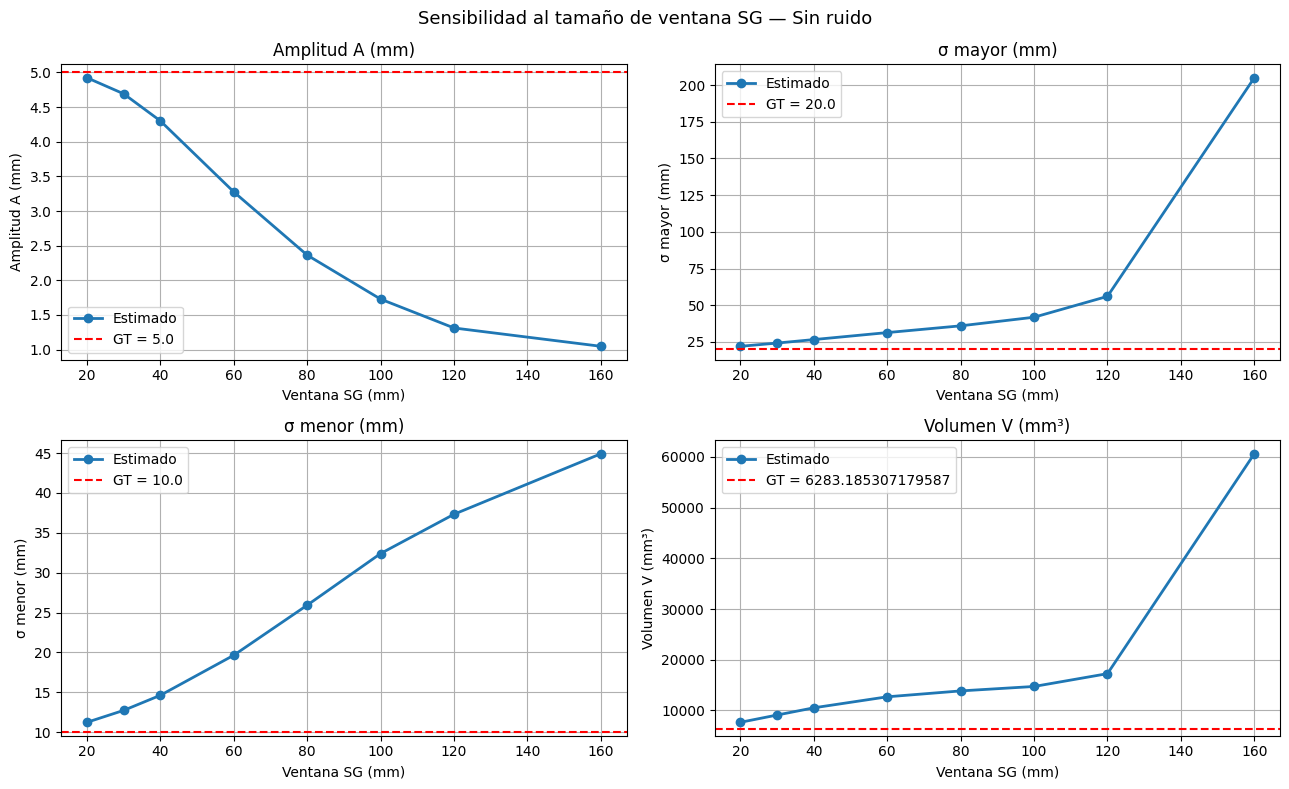

In [56]:
import pandas as pd

df_sens = pd.DataFrame(records)
gt_vals = {"A": GT_A, "sigma_mayor": GT_SY, "sigma_menor": GT_SX, "V": V_gt}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
metrics = [("A", "Amplitud A (mm)"), ("sigma_mayor", "σ mayor (mm)"),
           ("sigma_menor", "σ menor (mm)"), ("V", "Volumen V (mm³)")]

for ax, (metric, label) in zip(axes.flat, metrics):
    ax.plot(df_sens["win_mm"], df_sens[metric], 'o-', lw=2, label="Estimado")
    ax.axhline(gt_vals[metric], color='red', linestyle='--', label=f"GT = {gt_vals[metric]}")
    ax.set_xlabel("Ventana SG (mm)")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(); ax.grid(True)

plt.suptitle("Sensibilidad al tamaño de ventana SG — Sin ruido", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Conclusiones del Experimento 3

- **Warm start sin optimización:** Con superficie limpia (sin ruido), el filtro SG debe recuperar con precisión los parámetros del defecto gaussiano, confirmando la viabilidad de la inicialización analítica.
- **Dependencia de la ventana:** Existe una ventana óptima en torno a `4·σ_mayor`. Ventanas pequeñas subestiman σ; ventanas muy grandes promedian el defecto con la curvatura del cilindro.
- **Siguiente paso:** Experimento 3b — repetir con ruido de sensor gaussiano (σ_ruido ~ 0.1 mm) para cuantificar la degradación y motivar el refinamiento LM.

| Parámetro | Ground truth | Warm start | Error |
|---|---|---|---|
| Posición X | GT_X0 | mu_X | — |
| Posición Y | GT_Y0 | mu_Y | — |
| Amplitud A | GT_A | A_splat | — |
| σ mayor | GT_SY | sigma1_est | — |
| σ menor | GT_SX | sigma2_est | — |
| Volumen V | V_gt | V_splat | — |

*(Los valores se rellenan al ejecutar el notebook)*

## 9. Visualizaciones 3D del Splat

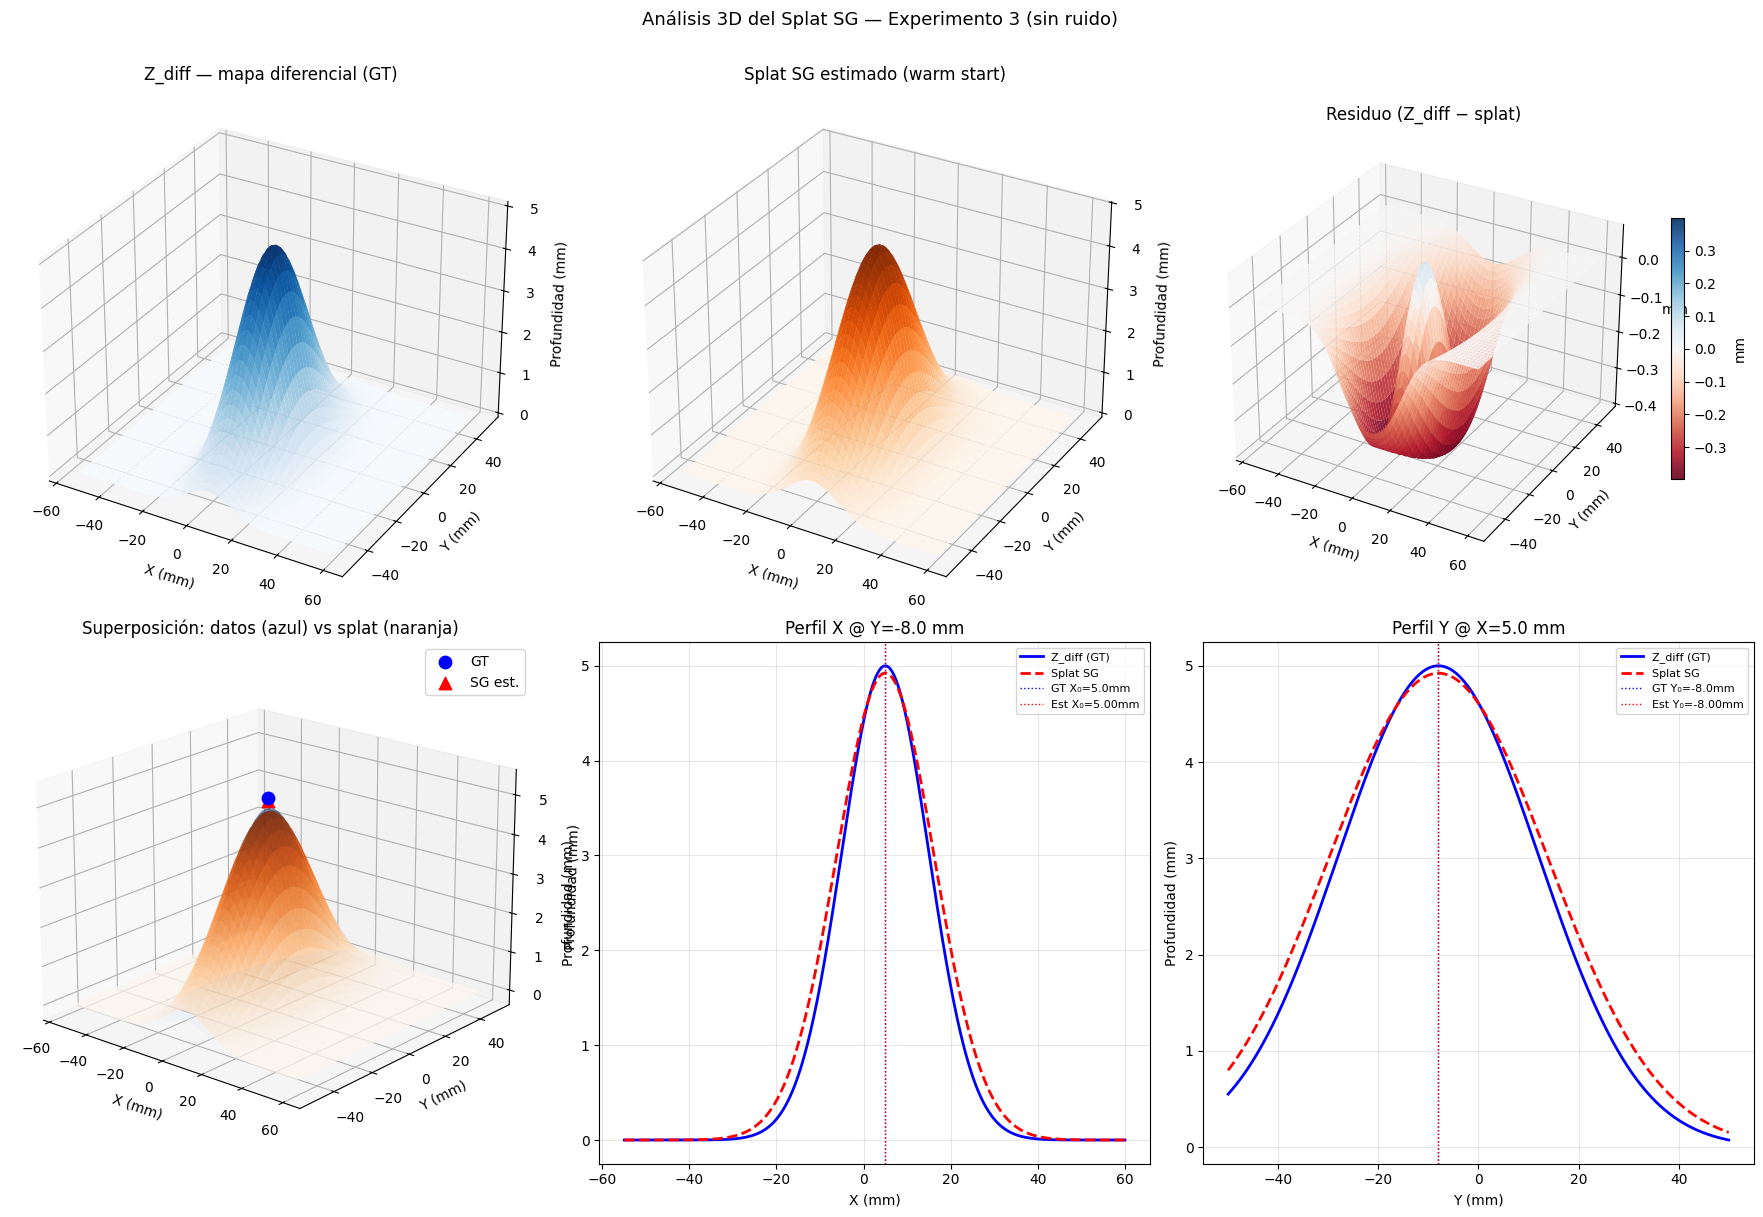

In [57]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── ROI alrededor del defecto (+/- 3*sigma_mayor) ────────────────────────────
margin = 3.0 * GT_SY  # 60 mm
ix0 = int(np.searchsorted(x_vec, mu_X - margin))
ix1 = int(np.searchsorted(x_vec, mu_X + margin))
iy0 = int(np.searchsorted(y_vec, mu_Y - margin))
iy1 = int(np.searchsorted(y_vec, mu_Y + margin))
ix0, ix1 = max(ix0, 0), min(ix1, N_COLS)
iy0, iy1 = max(iy0, 0), min(iy1, N_ROWS)

# Submuestreo para aligerar el render
step = 2
Xr = X_img[iy0:iy1:step, ix0:ix1:step]
Yr = Y_img[iy0:iy1:step, ix0:ix1:step]
Zd_r = Z_diff[iy0:iy1:step, ix0:ix1:step]          # datos
Zs_r = defect_splat[iy0:iy1:step, ix0:ix1:step]    # splat estimado
res_r = (Z_diff - defect_splat)[iy0:iy1:step, ix0:ix1:step]  # residuo

fig = plt.figure(figsize=(18, 12))

# ── Panel 1: solo Z_diff (GT en ROI) ─────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
ax1.plot_surface(Xr, Yr, Zd_r, cmap='Blues', alpha=0.9, rcount=60, ccount=60)
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)'); ax1.set_zlabel('Profundidad (mm)')
ax1.set_title('Z_diff — mapa diferencial (GT)')
ax1.view_init(elev=30, azim=-60)

# ── Panel 2: solo splat SG ───────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
ax2.plot_surface(Xr, Yr, Zs_r, cmap='Oranges', alpha=0.9, rcount=60, ccount=60)
ax2.set_xlabel('X (mm)'); ax2.set_ylabel('Y (mm)'); ax2.set_zlabel('Profundidad (mm)')
ax2.set_title('Splat SG estimado (warm start)')
ax2.view_init(elev=30, azim=-60)

# ── Panel 3: residuo ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3, projection='3d')
vr = np.abs(res_r).max()
surf3 = ax3.plot_surface(Xr, Yr, res_r, cmap='RdBu', alpha=0.9, rcount=60, ccount=60,
                         vmin=-vr, vmax=vr)
ax3.set_xlabel('X (mm)'); ax3.set_ylabel('Y (mm)'); ax3.set_zlabel('mm')
ax3.set_title('Residuo (Z_diff − splat)')
ax3.view_init(elev=30, azim=-60)
fig.colorbar(surf3, ax=ax3, shrink=0.5, label='mm')

# ── Panel 4: superposición Z_diff + splat ────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.plot_surface(Xr, Yr, Zd_r, cmap='Blues', alpha=0.35, rcount=60, ccount=60)
ax4.plot_surface(Xr, Yr, Zs_r, cmap='Oranges', alpha=0.65, rcount=60, ccount=60)
# Marcar centros
ax4.scatter([GT_X0], [GT_Y0], [GT_A * 1.05], color='blue', s=80, zorder=5, label='GT')
ax4.scatter([mu_X],  [mu_Y],  [A_splat * 1.05], color='red', s=80, marker='^', zorder=5, label='SG est.')
ax4.legend()
ax4.set_xlabel('X (mm)'); ax4.set_ylabel('Y (mm)'); ax4.set_zlabel('Profundidad (mm)')
ax4.set_title('Superposición: datos (azul) vs splat (naranja)')
ax4.view_init(elev=20, azim=-50)

# ── Panel 5: perfil XZ por Y=mu_Y ────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
row_mu = int(np.argmin(np.abs(y_vec - mu_Y)))
ax5.plot(x_vec[ix0:ix1], Z_diff[row_mu, ix0:ix1], 'b-', lw=2, label='Z_diff (GT)')
ax5.plot(x_vec[ix0:ix1], defect_splat[row_mu, ix0:ix1], 'r--', lw=2, label='Splat SG')
ax5.axvline(GT_X0, color='blue', lw=1, ls=':', label=f'GT X₀={GT_X0}mm')
ax5.axvline(mu_X, color='red',  lw=1, ls=':', label=f'Est X₀={mu_X:.2f}mm')
ax5.set_xlabel('X (mm)'); ax5.set_ylabel('Profundidad (mm)')
ax5.set_title(f'Perfil X @ Y={mu_Y:.1f} mm')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

# ── Panel 6: perfil YZ por X=mu_X ────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
col_mu = int(np.argmin(np.abs(x_vec - mu_X)))
ax6.plot(y_vec[iy0:iy1], Z_diff[iy0:iy1, col_mu], 'b-', lw=2, label='Z_diff (GT)')
ax6.plot(y_vec[iy0:iy1], defect_splat[iy0:iy1, col_mu], 'r--', lw=2, label='Splat SG')
ax6.axvline(GT_Y0, color='blue', lw=1, ls=':', label=f'GT Y₀={GT_Y0}mm')
ax6.axvline(mu_Y, color='red',  lw=1, ls=':', label=f'Est Y₀={mu_Y:.2f}mm')
ax6.set_xlabel('Y (mm)'); ax6.set_ylabel('Profundidad (mm)')
ax6.set_title(f'Perfil Y @ X={mu_X:.1f} mm')
ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

plt.suptitle('Análisis 3D del Splat SG — Experimento 3 (sin ruido)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

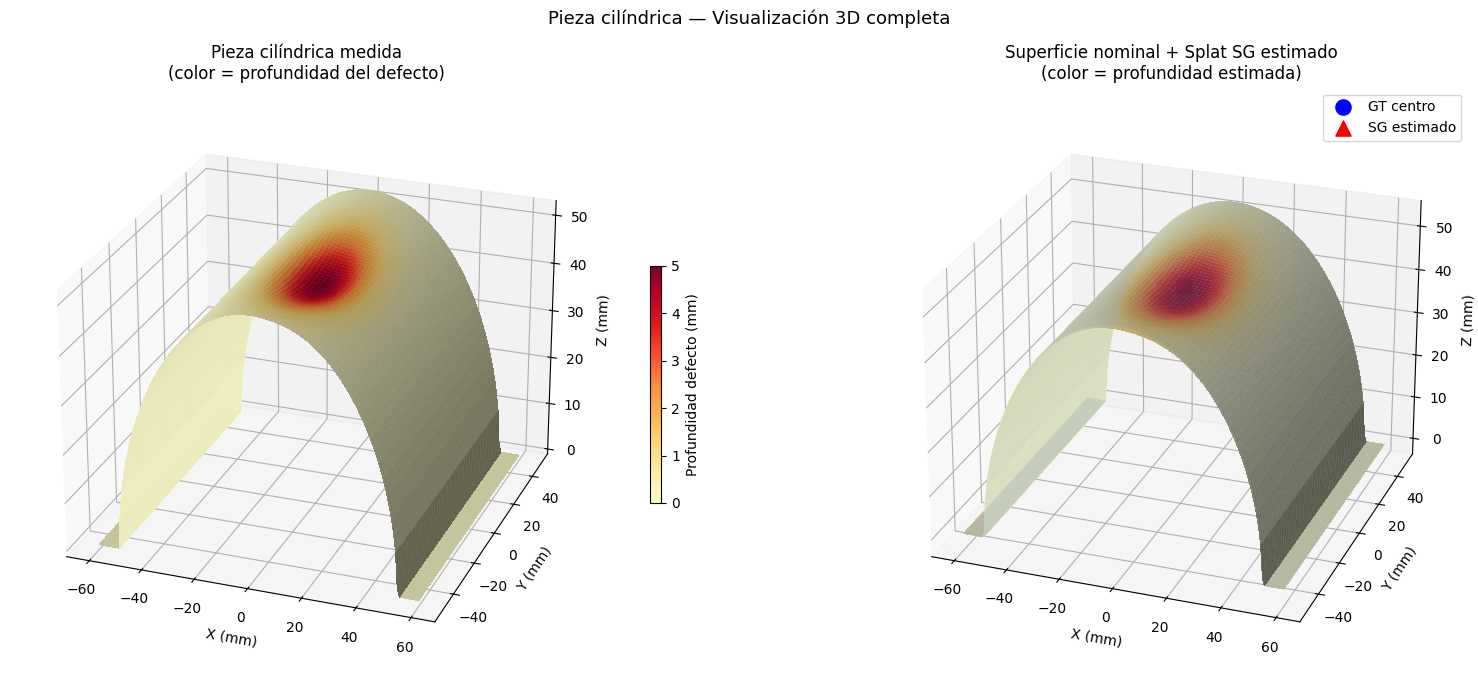

In [58]:
# ── 3D de la pieza completa coloreada por profundidad del defecto ─────────────
step3d = 4  # submuestreo para render ligero
Xs = X_img[::step3d, ::step3d]
Ys = Y_img[::step3d, ::step3d]
Zn = Z_nominal[::step3d, ::step3d]   # cilindro nominal (superficie fantasma)
Zi = Z_img[::step3d, ::step3d]       # pieza medida con el defecto
Dd = defect[::step3d, ::step3d]      # profundidad GT del defecto

norm_d = plt.Normalize(vmin=0, vmax=GT_A)
cmap_d = plt.cm.YlOrRd
face_colors = cmap_d(norm_d(Dd))

fig = plt.figure(figsize=(18, 7))

# ── Panel izq: cilindro medido + coloreado por defecto ───────────────────────
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(Xs, Ys, Zi, facecolors=face_colors, alpha=0.95,
                 rcount=100, ccount=100, linewidth=0, antialiased=False)
# Colorbar proxy
sm = plt.cm.ScalarMappable(cmap=cmap_d, norm=norm_d)
sm.set_array([])
fig.colorbar(sm, ax=ax1, shrink=0.4, label='Profundidad defecto (mm)')
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)'); ax1.set_zlabel('Z (mm)')
ax1.set_title('Pieza cilíndrica medida\n(color = profundidad del defecto)')
ax1.view_init(elev=25, azim=-70)

# ── Panel der: nominal (translúcido) + splat SG proyectado sobre cilindro ─────
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Cilindro nominal en gris semitransparente
ax2.plot_surface(Xs, Ys, Zn, color='lightsteelblue', alpha=0.25,
                 rcount=80, ccount=80, linewidth=0)

# Splat SG elevado sobre el cilindro (superficie nominal - splat)
Zsp = Z_nominal[::step3d, ::step3d] - defect_splat[::step3d, ::step3d]
face_sp = cmap_d(norm_d(defect_splat[::step3d, ::step3d]))
ax2.plot_surface(Xs, Ys, Zsp, facecolors=face_sp, alpha=0.90,
                 rcount=100, ccount=100, linewidth=0, antialiased=False)

# Marcar los centros estimado y GT
Z_gt_center = float(np.sqrt(max(R**2 - GT_X0**2, 0))) - GT_A * 0.5
Z_est_center = float(np.sqrt(max(R**2 - mu_X**2, 0))) - A_splat * 0.5
ax2.scatter([GT_X0], [GT_Y0], [Z_gt_center], color='blue', s=120, zorder=10, label='GT centro')
ax2.scatter([mu_X],  [mu_Y],  [Z_est_center], color='red',  s=120, marker='^', zorder=10, label='SG estimado')
ax2.legend(loc='upper right')
ax2.set_xlabel('X (mm)'); ax2.set_ylabel('Y (mm)'); ax2.set_zlabel('Z (mm)')
ax2.set_title('Superficie nominal + Splat SG estimado\n(color = profundidad estimada)')
ax2.view_init(elev=25, azim=-70)

plt.suptitle('Pieza cilíndrica — Visualización 3D completa', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Warm Start (ventana mala) + Optimización LM del Splat

El warm start con ventana 80mm da un splat muy sesgado (A≈2.36mm, σ sobreestimadas).
Partiendo de ese punto inicial *intencionalmente malo*, ajustamos una gaussiana 2D
sobre `Z_diff` dentro de la máscara usando **Levenberg-Marquardt** (scipy).

Modelo: $f(x,y) = A \cdot \exp\!\left(-\frac{u^2}{2\sigma_x^2} - \frac{v^2}{2\sigma_y^2}\right)$
con rotación $\theta$, donde $u, v$ son los ejes principales del splat.

In [59]:
# ── Warm start con ventana MALA (80 mm) ──────────────────────────────────────
WIN_BAD_MM = 80.0
WIN_BAD_PX = int(np.round(WIN_BAD_MM / min(dx, dy)))
WIN_BAD_PX = WIN_BAD_PX if WIN_BAD_PX % 2 == 1 else WIN_BAD_PX + 1

coeffs_bad_px = sg2d_jacobian_projection_cv2(Z_diff, window_size=WIN_BAD_PX)
coeffs_bad_ph = coeffs_to_physical(coeffs_bad_px, dx, dy)

f0_bad = coeffs_bad_ph[..., 5]
f0_bad_masked = np.where(mask_defect, f0_bad, -np.inf)
pr_b, pc_b = np.unravel_index(np.argmax(f0_bad_masked), f0_bad_masked.shape)

ab, bb, cb, db, eb, f0b = coeffs_bad_ph[pr_b, pc_b, :]
H_bad = np.array([[2*ab, cb], [cb, 2*bb]])
delta_b = -np.linalg.solve(H_bad, [db, eb])
x0_ws  = float(x_vec[pc_b] + delta_b[0])
y0_ws  = float(y_vec[pr_b] + delta_b[1])
A_ws   = float(f0b)
Sigma_ws = -A_ws * np.linalg.inv(H_bad)

# Extraer sx, sy, theta de Sigma_ws
evals_ws, evecs_ws = np.linalg.eigh(Sigma_ws)
order = np.argsort(evals_ws)[::-1]
evals_ws = evals_ws[order]
evecs_ws = evecs_ws[:, order]
sx_ws = float(np.sqrt(np.abs(evals_ws[0])))   # sigma del eje mayor
sy_ws = float(np.sqrt(np.abs(evals_ws[1])))   # sigma del eje menor
theta_ws = float(np.arctan2(evecs_ws[1, 0], evecs_ws[0, 0]))  # ángulo del eje mayor

print("═══ Warm Start (ventana 80 mm — mala) ════════════════════════")
print(f"  x0 = {x0_ws:.4f} mm  (GT={GT_X0})")
print(f"  y0 = {y0_ws:.4f} mm  (GT={GT_Y0})")
print(f"  A  = {A_ws:.4f} mm  (GT={GT_A})")
print(f"  σ_mayor = {sx_ws:.4f} mm  (GT σ_may={GT_SY})")
print(f"  σ_menor = {sy_ws:.4f} mm  (GT σ_men={GT_SX})")
print(f"  θ  = {np.degrees(theta_ws):.2f}°")
V_ws = A_ws * 2 * np.pi * sx_ws * sy_ws
print(f"  V  = {V_ws:.2f} mm³  (GT={V_gt:.2f})")
print(f"  Error A = {100*(A_ws-GT_A)/GT_A:.1f}%,  Error V = {100*(V_ws-V_gt)/V_gt:.1f}%")

═══ Warm Start (ventana 80 mm — mala) ════════════════════════
  x0 = 4.9958 mm  (GT=5.0)
  y0 = -7.9802 mm  (GT=-8.0)
  A  = 2.3634 mm  (GT=5.0)
  σ_mayor = 35.9651 mm  (GT σ_may=20.0)
  σ_menor = 25.9298 mm  (GT σ_men=10.0)
  θ  = 90.00°
  V  = 13848.53 mm³  (GT=6283.19)
  Error A = -52.7%,  Error V = 120.4%


In [61]:
from scipy.optimize import least_squares

# ── Datos observados: Z_diff dentro de la máscara ────────────────────────────
rows_m, cols_m = np.where(mask_defect)
x_obs = x_vec[cols_m]
y_obs = y_vec[rows_m]
z_obs = Z_diff[rows_m, cols_m]

def gauss2d_rotated(params, x, y):
    """Gaussiana 2D con ejes rotados."""
    A_p, x0_p, y0_p, sx_p, sy_p, th_p = params
    cos_t, sin_t = np.cos(th_p), np.sin(th_p)
    dx_p = x - x0_p
    dy_p = y - y0_p
    u =  dx_p * cos_t + dy_p * sin_t
    v = -dx_p * sin_t + dy_p * cos_t
    return A_p * np.exp(-0.5 * (u**2 / sx_p**2 + v**2 / sy_p**2))

def residuals(params):
    return gauss2d_rotated(params, x_obs, y_obs) - z_obs

# ── Punto inicial: warm start con la ventana mala ─────────────────────────────
p0 = [A_ws, x0_ws, y0_ws, sx_ws, sy_ws, theta_ws]
print("Punto inicial (warm start 80mm):")
print(f"  p0 = A={p0[0]:.3f}, x0={p0[1]:.3f}, y0={p0[2]:.3f}, "
      f"sx={p0[3]:.3f}, sy={p0[4]:.3f}, θ={np.degrees(p0[5]):.2f}°")

# ── Optimización LM (TRF con cotas) ──────────────────────────────────────────
bounds_lo = [0,       -FOV_X/2, -FOV_Y/2, 0.1,  0.1,  -np.pi]
bounds_hi = [GT_A*3,   FOV_X/2,  FOV_Y/2, 200., 200.,  np.pi]

# Clipear p0 para que quede estrictamente dentro de las cotas
p0_clipped = [float(np.clip(v, lo + 1e-6, hi - 1e-6))
              for v, lo, hi in zip(p0, bounds_lo, bounds_hi)]

result_lm = least_squares(
    residuals, p0_clipped,
    bounds=(bounds_lo, bounds_hi),
    method='trf',
    loss='linear',
    xtol=1e-9, ftol=1e-9, gtol=1e-9,
    max_nfev=10_000,
    verbose=0
)

A_lm, x0_lm, y0_lm, sx_lm, sy_lm, theta_lm = result_lm.x
V_lm = A_lm * 2 * np.pi * sx_lm * sy_lm

print(f"\nConvergencia LM: {result_lm.message}")
print(f"  nfev={result_lm.nfev}, cost={result_lm.cost:.4e}")
print("\n═══ Resultado tras optimización LM ════════════════════════════")
print(f"  x0 = {x0_lm:.4f} mm  (GT={GT_X0}, err={x0_lm-GT_X0:+.4f})")
print(f"  y0 = {y0_lm:.4f} mm  (GT={GT_Y0}, err={y0_lm-GT_Y0:+.4f})")
print(f"  A  = {A_lm:.4f} mm  (GT={GT_A}, err={A_lm-GT_A:+.4f})")
s1_lm = max(sx_lm, sy_lm)
s2_lm = min(sx_lm, sy_lm)
print(f"  σ_mayor = {s1_lm:.4f} mm  (GT={GT_SY}, err={s1_lm-GT_SY:+.4f})")
print(f"  σ_menor = {s2_lm:.4f} mm  (GT={GT_SX}, err={s2_lm-GT_SX:+.4f})")
print(f"  θ  = {np.degrees(theta_lm):.2f}°")
print(f"  V  = {V_lm:.4f} mm³  (GT={V_gt:.4f}, err={100*(V_lm-V_gt)/V_gt:+.2f}%)")

Punto inicial (warm start 80mm):
  p0 = A=2.363, x0=4.996, y0=-7.980, sx=35.965, sy=25.930, θ=90.00°

Convergencia LM: `gtol` termination condition is satisfied.
  nfev=9, cost=2.0962e-25

═══ Resultado tras optimización LM ════════════════════════════
  x0 = 5.0000 mm  (GT=5.0, err=+0.0000)
  y0 = -8.0000 mm  (GT=-8.0, err=+0.0000)
  A  = 5.0000 mm  (GT=5.0, err=-0.0000)
  σ_mayor = 20.0000 mm  (GT=20.0, err=+0.0000)
  σ_menor = 10.0000 mm  (GT=10.0, err=+0.0000)
  θ  = 90.00°
  V  = 6283.1853 mm³  (GT=6283.1853, err=-0.00%)


   Parámetro        GT    WS 80mm   LM opt.  Err WS %  Err LM %
     X₀ (mm)    5.0000     4.9958    5.0000    0.0833    0.0000
     Y₀ (mm)   -8.0000    -7.9802   -8.0000    0.2473    0.0000
      A (mm)    5.0000     2.3634    5.0000   52.7314    0.0000
σ_mayor (mm)   20.0000    35.9651   20.0000   79.8257    0.0000
σ_menor (mm)   10.0000    25.9298   10.0000  159.2979    0.0000
     V (mm³) 6283.1853 13848.5285 6283.1853  120.4062    0.0000


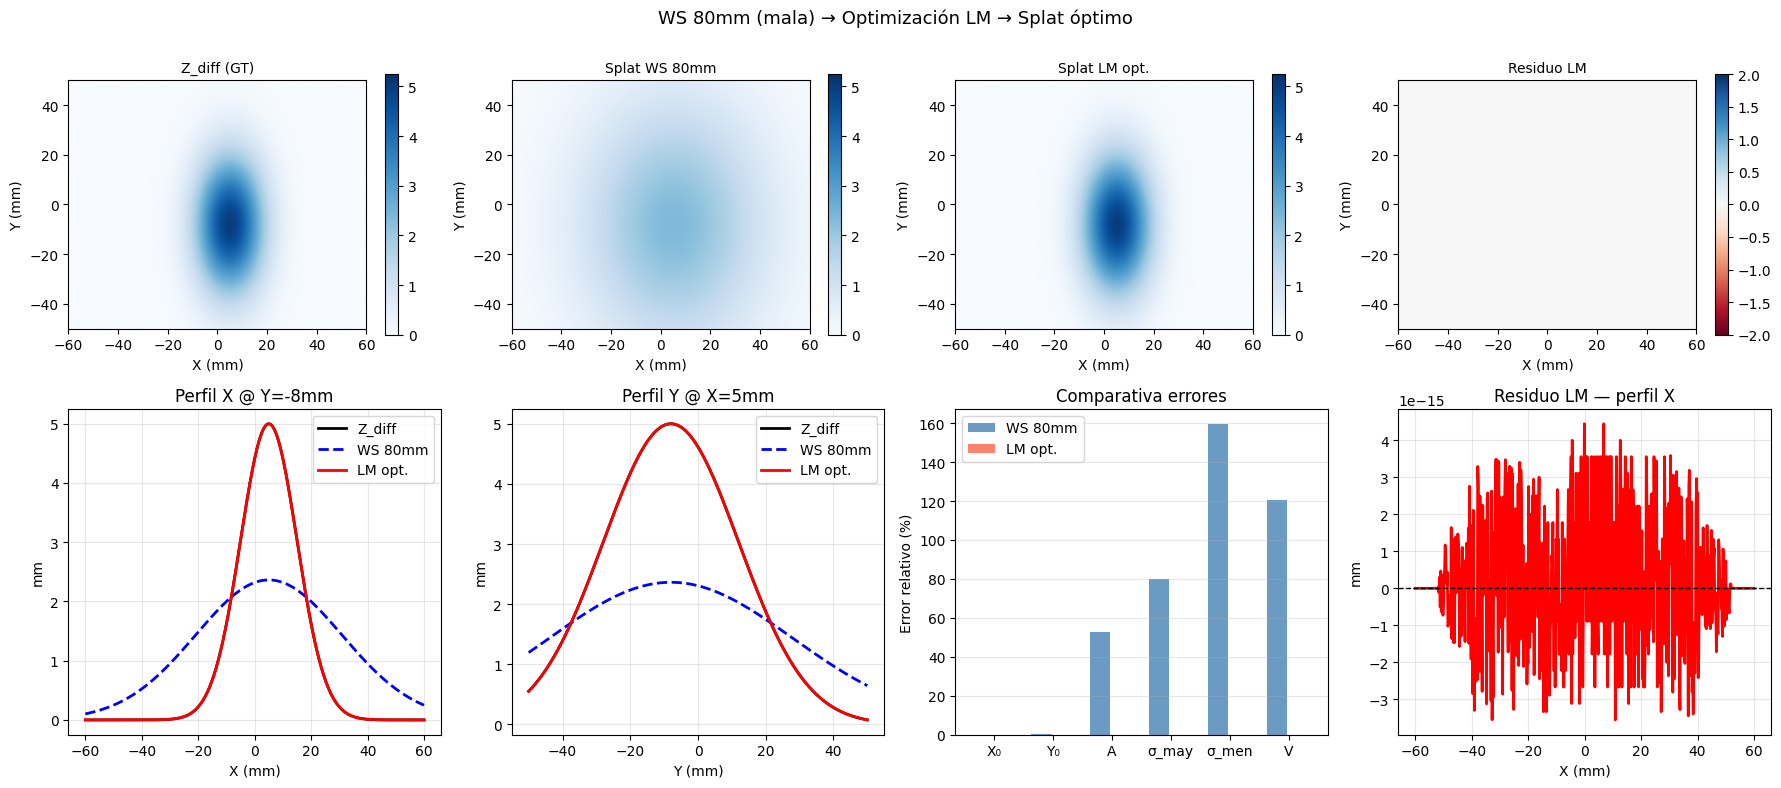

In [62]:
# ── Tabla comparativa: GT vs Warm Start vs LM ────────────────────────────────
import pandas as pd

rows_cmp = [
    ("X₀ (mm)",      GT_X0,  x0_ws,  x0_lm),
    ("Y₀ (mm)",      GT_Y0,  y0_ws,  y0_lm),
    ("A (mm)",       GT_A,   A_ws,   A_lm),
    ("σ_mayor (mm)", GT_SY,  sx_ws,  s1_lm),
    ("σ_menor (mm)", GT_SX,  sy_ws,  s2_lm),
    ("V (mm³)",      V_gt,   V_ws,   V_lm),
]
df_cmp = pd.DataFrame(rows_cmp, columns=["Parámetro", "GT", "WS 80mm", "LM opt."])
df_cmp["Err WS %"] = 100 * (df_cmp["WS 80mm"] - df_cmp["GT"]).abs() / df_cmp["GT"].abs()
df_cmp["Err LM %"] = 100 * (df_cmp["LM opt."] - df_cmp["GT"]).abs() / df_cmp["GT"].abs()
print(df_cmp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ── Visualización comparativa ─────────────────────────────────────────────────
# Reconstruir los mapas de cada splat
gauss_ws = gauss2d_rotated([A_ws, x0_ws, y0_ws, sx_ws, sy_ws, theta_ws], X_img, Y_img)
gauss_lm = gauss2d_rotated([A_lm, x0_lm, y0_lm, sx_lm, sy_lm, theta_lm], X_img, Y_img)
res_ws   = Z_diff - gauss_ws
res_lm   = Z_diff - gauss_lm

# ROI centrada en el defecto
margin2 = 3.5 * GT_SY
jx0 = max(int(np.searchsorted(x_vec, GT_X0 - margin2)), 0)
jx1 = min(int(np.searchsorted(x_vec, GT_X0 + margin2)), N_COLS)
jy0 = max(int(np.searchsorted(y_vec, GT_Y0 - margin2)), 0)
jy1 = min(int(np.searchsorted(y_vec, GT_Y0 + margin2)), N_ROWS)

ext2 = [x_vec[jx0], x_vec[jx1-1], y_vec[jy0], y_vec[jy1-1]]
vmax_c = GT_A * 1.05
vmax_r = GT_A * 0.4

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

def show(ax, data, title, vmax=None, cmap='Blues', vmin=None):
    vm = vmax if vmax else np.abs(data[jy0:jy1, jx0:jx1]).max()
    vi = vmin if vmin is not None else 0
    im = ax.imshow(data[jy0:jy1, jx0:jx1], origin='lower', extent=ext2,
                   cmap=cmap, vmin=vi, vmax=vm)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)")
    plt.colorbar(im, ax=ax, shrink=0.8)
    return im

show(axes[0, 0], Z_diff,    "Z_diff (GT)",             vmax=vmax_c)
show(axes[0, 1], gauss_ws,  "Splat WS 80mm",           vmax=vmax_c)
show(axes[0, 2], gauss_lm,  "Splat LM opt.",           vmax=vmax_c)
show(axes[0, 3], Z_diff - gauss_lm, "Residuo LM",
     vmax=vmax_r, cmap='RdBu', vmin=-vmax_r)

# Perfiles X
row_gt = int(np.argmin(np.abs(y_vec - GT_Y0)))
axes[1, 0].plot(x_vec[jx0:jx1], Z_diff[row_gt, jx0:jx1], 'k-', lw=2, label='Z_diff')
axes[1, 0].plot(x_vec[jx0:jx1], gauss_ws[row_gt, jx0:jx1], 'b--', lw=2, label='WS 80mm')
axes[1, 0].plot(x_vec[jx0:jx1], gauss_lm[row_gt, jx0:jx1], 'r-', lw=2, label='LM opt.')
axes[1, 0].set_xlabel("X (mm)"); axes[1, 0].set_ylabel("mm")
axes[1, 0].set_title(f"Perfil X @ Y={GT_Y0:.0f}mm"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Perfiles Y
col_gt = int(np.argmin(np.abs(x_vec - GT_X0)))
axes[1, 1].plot(y_vec[jy0:jy1], Z_diff[jy0:jy1, col_gt], 'k-', lw=2, label='Z_diff')
axes[1, 1].plot(y_vec[jy0:jy1], gauss_ws[jy0:jy1, col_gt], 'b--', lw=2, label='WS 80mm')
axes[1, 1].plot(y_vec[jy0:jy1], gauss_lm[jy0:jy1, col_gt], 'r-', lw=2, label='LM opt.')
axes[1, 1].set_xlabel("Y (mm)"); axes[1, 1].set_ylabel("mm")
axes[1, 1].set_title(f"Perfil Y @ X={GT_X0:.0f}mm"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

# Convergencia: barras de error relativo
params_names = ["X₀", "Y₀", "A", "σ_may", "σ_men", "V"]
errs_ws = df_cmp["Err WS %"].values
errs_lm = df_cmp["Err LM %"].values
xp = np.arange(len(params_names))
axes[1, 2].bar(xp - 0.2, errs_ws, 0.35, label="WS 80mm", color='steelblue', alpha=0.8)
axes[1, 2].bar(xp + 0.2, errs_lm, 0.35, label="LM opt.",  color='tomato',    alpha=0.8)
axes[1, 2].set_xticks(xp); axes[1, 2].set_xticklabels(params_names)
axes[1, 2].set_ylabel("Error relativo (%)"); axes[1, 2].set_title("Comparativa errores")
axes[1, 2].legend(); axes[1, 2].grid(axis='y', alpha=0.3)

# Residuo LM perfil X
axes[1, 3].plot(x_vec[jx0:jx1], res_lm[row_gt, jx0:jx1], 'r-', lw=2)
axes[1, 3].axhline(0, color='k', lw=1, ls='--')
axes[1, 3].set_xlabel("X (mm)"); axes[1, 3].set_ylabel("mm")
axes[1, 3].set_title("Residuo LM — perfil X"); axes[1, 3].grid(alpha=0.3)

plt.suptitle("WS 80mm (mala) → Optimización LM → Splat óptimo", fontsize=13)
plt.tight_layout()
plt.show()

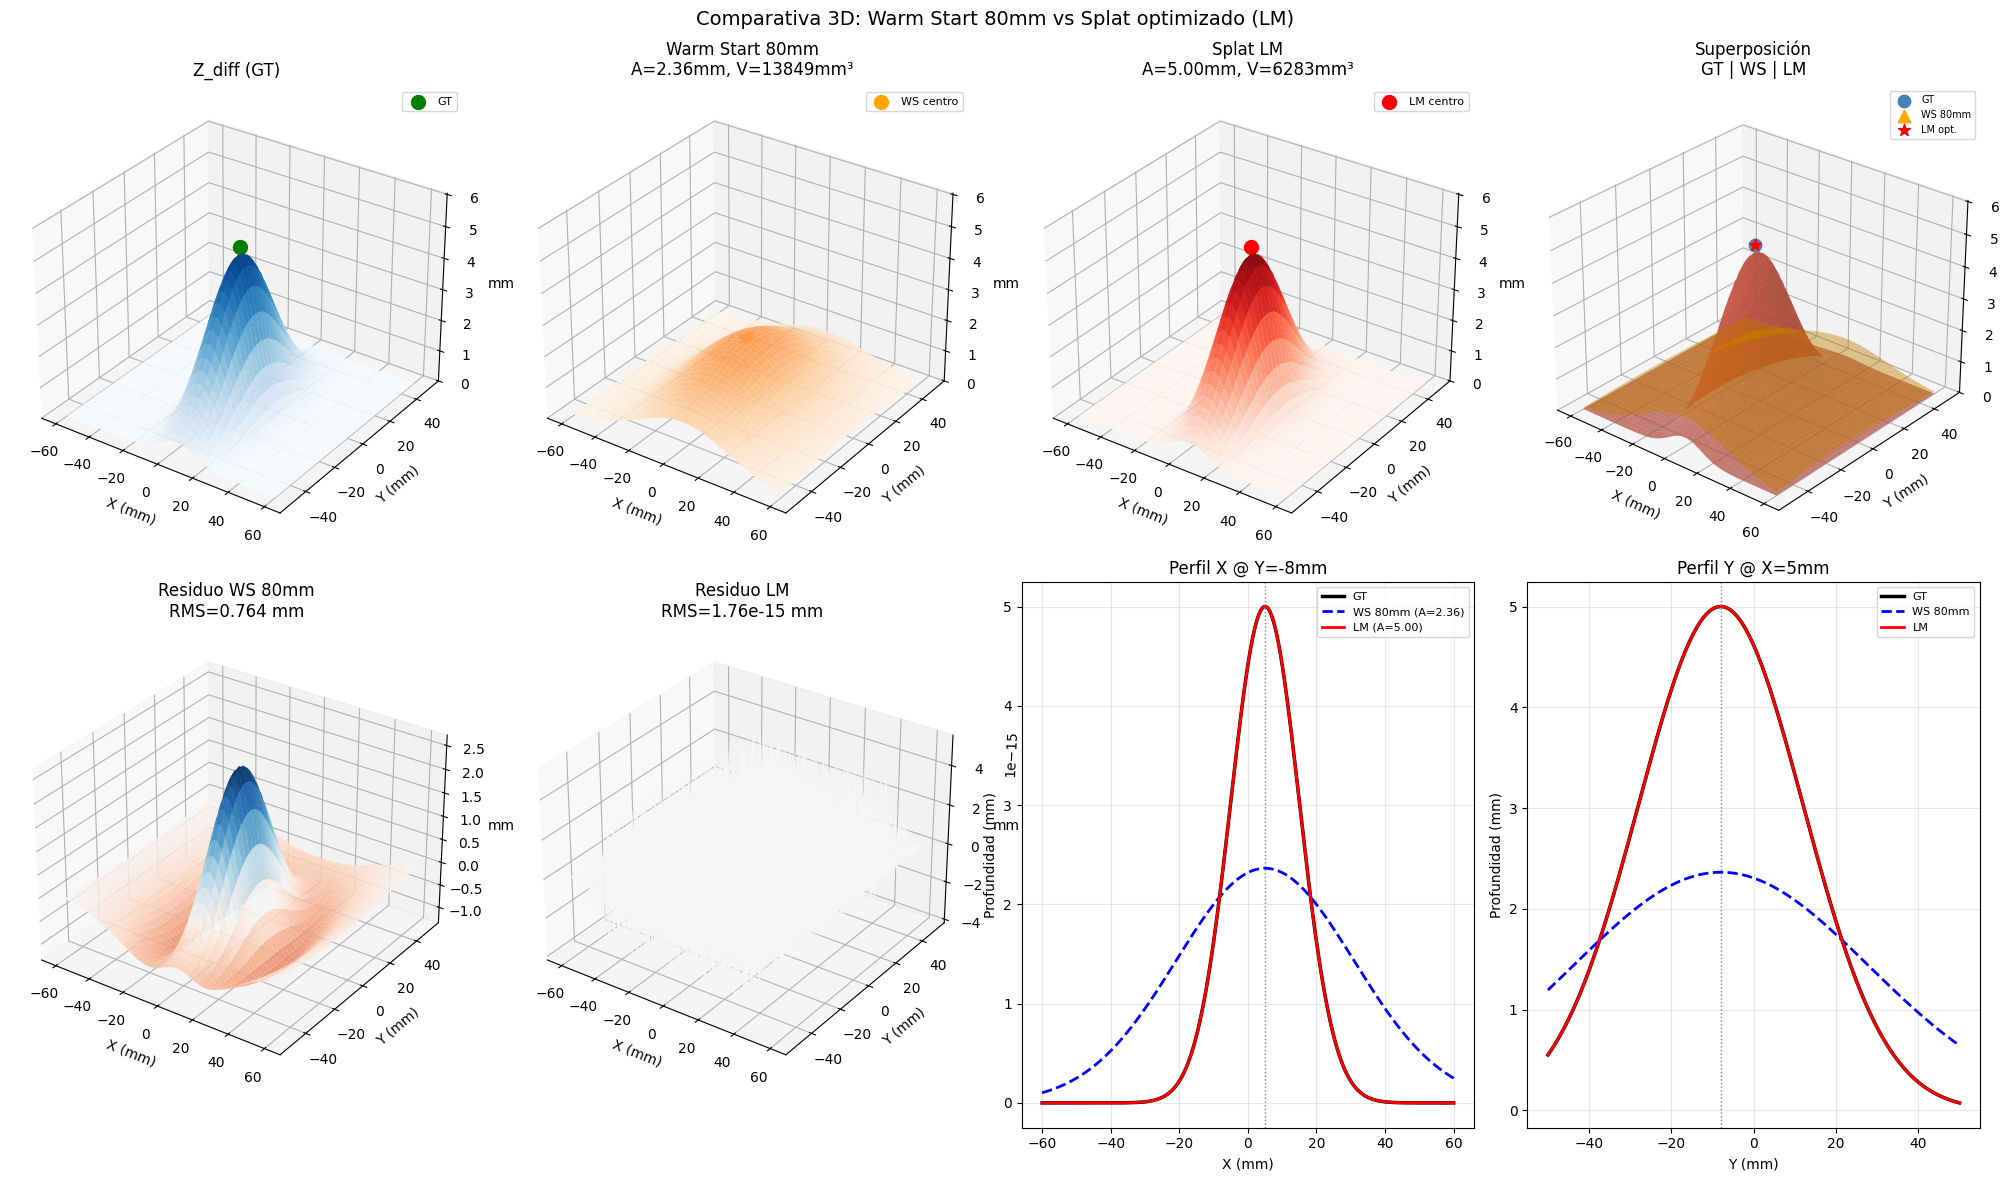

In [63]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── Sub-grid ROI ──────────────────────────────────────────────────────────────
st = 2   # submuestreo para render
Xroi = X_img[jy0:jy1:st, jx0:jx1:st]
Yroi = Y_img[jy0:jy1:st, jx0:jx1:st]
Zdata  = Z_diff[jy0:jy1:st, jx0:jx1:st]
Zws    = gauss_ws[jy0:jy1:st, jx0:jx1:st]
Zlm    = gauss_lm[jy0:jy1:st, jx0:jx1:st]
Rws    = (Z_diff - gauss_ws)[jy0:jy1:st, jx0:jx1:st]
Rlm    = (Z_diff - gauss_lm)[jy0:jy1:st, jx0:jx1:st]

rc = 50   # resolución de render
vmax3 = GT_A * 1.05

fig = plt.figure(figsize=(20, 12))

# ── Fila superior: superficies 3D ─────────────────────────────────────────────

# Panel 1: datos
ax1 = fig.add_subplot(2, 4, 1, projection='3d')
ax1.plot_surface(Xroi, Yroi, Zdata, cmap='Blues', alpha=0.95,
                 rcount=rc, ccount=rc, vmin=0, vmax=vmax3)
ax1.scatter([GT_X0], [GT_Y0], [GT_A * 1.05], color='green', s=100,
            zorder=5, label='GT')
ax1.set_title('Z_diff (GT)', pad=8)
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)'); ax1.set_zlabel('mm')
ax1.set_zlim(0, vmax3 * 1.15)
ax1.view_init(elev=30, azim=-55)
ax1.legend(fontsize=8)

# Panel 2: warm start (80mm — mala)
ax2 = fig.add_subplot(2, 4, 2, projection='3d')
ax2.plot_surface(Xroi, Yroi, Zws, cmap='Oranges', alpha=0.95,
                 rcount=rc, ccount=rc, vmin=0, vmax=vmax3)
ax2.scatter([x0_ws], [y0_ws], [A_ws * 1.05], color='orange', s=100,
            zorder=5, label=f'WS centro')
ax2.set_title(f'Warm Start 80mm\nA={A_ws:.2f}mm, V={V_ws:.0f}mm³', pad=8)
ax2.set_xlabel('X (mm)'); ax2.set_ylabel('Y (mm)'); ax2.set_zlabel('mm')
ax2.set_zlim(0, vmax3 * 1.15)
ax2.view_init(elev=30, azim=-55)
ax2.legend(fontsize=8)

# Panel 3: splat LM
ax3 = fig.add_subplot(2, 4, 3, projection='3d')
ax3.plot_surface(Xroi, Yroi, Zlm, cmap='Reds', alpha=0.95,
                 rcount=rc, ccount=rc, vmin=0, vmax=vmax3)
ax3.scatter([x0_lm], [y0_lm], [A_lm * 1.05], color='red', s=100,
            zorder=5, label='LM centro')
ax3.set_title(f'Splat LM\nA={A_lm:.2f}mm, V={V_lm:.0f}mm³', pad=8)
ax3.set_xlabel('X (mm)'); ax3.set_ylabel('Y (mm)'); ax3.set_zlabel('mm')
ax3.set_zlim(0, vmax3 * 1.15)
ax3.view_init(elev=30, azim=-55)
ax3.legend(fontsize=8)

# Panel 4: superposición semitransparente GT + WS + LM
ax4 = fig.add_subplot(2, 4, 4, projection='3d')
ax4.plot_surface(Xroi, Yroi, Zdata, color='steelblue',  alpha=0.25, rcount=rc, ccount=rc)
ax4.plot_surface(Xroi, Yroi, Zws,   color='orange',     alpha=0.45, rcount=rc, ccount=rc)
ax4.plot_surface(Xroi, Yroi, Zlm,   color='tomato',     alpha=0.65, rcount=rc, ccount=rc)
ax4.scatter([GT_X0],  [GT_Y0],  [GT_A  * 1.05], color='steelblue', s=80,
            marker='o', zorder=5, label='GT')
ax4.scatter([x0_ws],  [y0_ws],  [A_ws  * 1.05], color='orange',    s=80,
            marker='^', zorder=5, label='WS 80mm')
ax4.scatter([x0_lm],  [y0_lm],  [A_lm  * 1.05], color='red',       s=80,
            marker='*', zorder=5, label='LM opt.')
ax4.set_title('Superposición\nGT | WS | LM', pad=8)
ax4.set_xlabel('X (mm)'); ax4.set_ylabel('Y (mm)'); ax4.set_zlabel('mm')
ax4.set_zlim(0, vmax3 * 1.15)
ax4.view_init(elev=28, azim=-50)
ax4.legend(fontsize=7, loc='upper right')

# ── Fila inferior: residuos 3D + perfiles ────────────────────────────────────

# Panel 5: residuo WS (3D)
vr3 = max(np.abs(Rws).max(), 0.1)
ax5 = fig.add_subplot(2, 4, 5, projection='3d')
ax5.plot_surface(Xroi, Yroi, Rws, cmap='RdBu', alpha=0.9,
                 rcount=rc, ccount=rc, vmin=-vr3, vmax=vr3)
ax5.set_title(f'Residuo WS 80mm\nRMS={np.sqrt((Rws**2).mean()):.3f} mm', pad=8)
ax5.set_xlabel('X (mm)'); ax5.set_ylabel('Y (mm)'); ax5.set_zlabel('mm')
ax5.view_init(elev=30, azim=-55)

# Panel 6: residuo LM (3D)
vr3lm = max(np.abs(Rlm).max(), 1e-9)
ax6 = fig.add_subplot(2, 4, 6, projection='3d')
ax6.plot_surface(Xroi, Yroi, Rlm, cmap='RdBu', alpha=0.9,
                 rcount=rc, ccount=rc, vmin=-vr3lm, vmax=vr3lm)
ax6.set_title(f'Residuo LM\nRMS={np.sqrt((Rlm**2).mean()):.2e} mm', pad=8)
ax6.set_xlabel('X (mm)'); ax6.set_ylabel('Y (mm)'); ax6.set_zlabel('mm')
ax6.view_init(elev=30, azim=-55)

# Panel 7: perfil X
row_p = int(np.argmin(np.abs(y_vec - GT_Y0)))
ax7 = fig.add_subplot(2, 4, 7)
ax7.plot(x_vec[jx0:jx1], Z_diff[row_p, jx0:jx1],     'k-',  lw=2.5, label='GT')
ax7.plot(x_vec[jx0:jx1], gauss_ws[row_p, jx0:jx1],   'b--', lw=2,   label=f'WS 80mm (A={A_ws:.2f})')
ax7.plot(x_vec[jx0:jx1], gauss_lm[row_p, jx0:jx1],   'r-',  lw=2,   label=f'LM (A={A_lm:.2f})')
ax7.axvline(GT_X0, color='gray', lw=1, ls=':')
ax7.set_xlabel('X (mm)'); ax7.set_ylabel('Profundidad (mm)')
ax7.set_title(f'Perfil X @ Y={GT_Y0:.0f}mm')
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

# Panel 8: perfil Y
col_p = int(np.argmin(np.abs(x_vec - GT_X0)))
ax8 = fig.add_subplot(2, 4, 8)
ax8.plot(y_vec[jy0:jy1], Z_diff[jy0:jy1, col_p],     'k-',  lw=2.5, label='GT')
ax8.plot(y_vec[jy0:jy1], gauss_ws[jy0:jy1, col_p],   'b--', lw=2,   label=f'WS 80mm')
ax8.plot(y_vec[jy0:jy1], gauss_lm[jy0:jy1, col_p],   'r-',  lw=2,   label=f'LM')
ax8.axvline(GT_Y0, color='gray', lw=1, ls=':')
ax8.set_xlabel('Y (mm)'); ax8.set_ylabel('Profundidad (mm)')
ax8.set_title(f'Perfil Y @ X={GT_X0:.0f}mm')
ax8.legend(fontsize=8); ax8.grid(alpha=0.3)

plt.suptitle('Comparativa 3D: Warm Start 80mm vs Splat optimizado (LM)', fontsize=14)
plt.tight_layout()
plt.show()